# Day 5 — LangGraph: From Tool Calling to Graph Orchestration

**What we'll build:** The same tool-calling system from Day 4 (web search + summarize), plus a new note-saving tool — but this time orchestrated as a **graph** using LangGraph.

**What you'll learn:**
- How to define a shared **State** that flows between steps
- How to write **Nodes** — simple functions that do one job each
- How to use **Conditional Edges** to route queries to the right tool
- How to **visualize** your workflow as an actual graph

**Why LangGraph over the manual loop?**

In Day 4 we built the tool-calling loop two ways: a manual JSON loop and a ReAct agent. Both work, but both are **linear** — one step after another. LangGraph lets us define the workflow as a **graph** with branches, making it easier to debug, extend, and control.

---
## 1. Setup

In [ ]:
!pip install -q langchain langchain-ollama langchain-community tavily-python langgraph

In [1]:
import os
import json
from datetime import datetime

from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from dotenv import load_dotenv

load_dotenv()

# Set your Tavily API key
# os.environ["TAVILY_API_KEY"] = "your-tavily-api-key-here"

c:\Users\shiva\.pyenv\pyenv-win\versions\3.12.10\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
# Initialize the LLM (same as Day 4)
llm = ChatOllama(model="llama3.2:3b", temperature=0)

# Quick test
print(llm.invoke("Say hello in one sentence.").content)

Hello!


---
## 2. Define Our Tools

Same two tools from Day 4, plus one new one: **save_note**.

These are just regular Python functions — LangGraph doesn't change how tools work.

### Tool 1 — Web Search

Searches the web using Tavily and returns formatted results.

In [3]:
@tool
def web_search(query: str) -> str:
    """Search the web for real-time information on any topic."""
    search = TavilySearchResults(max_results=3)
    results = search.invoke({"query": query})

    output = ""
    for r in results:
        output += f"- {r['content']}\n\n"
    return output.strip()

### Tool 2 — Summarize

Takes a long text and returns a short summary using the LLM.

In [4]:
@tool
def summarize(text: str) -> str:
    """Summarize a long piece of text into a short paragraph."""
    response = llm.invoke(f"Summarize the following text in 2-3 sentences:\n\n{text}")
    return response.content

### Tool 3 — Save Note (NEW)

Takes any text (like a chat answer) and saves it as a markdown note file. This is the kind of tool the NotebookLM clone will use.

In [5]:
# Create a folder for saved notes
os.makedirs("notes", exist_ok=True)


@tool
def save_note(text: str) -> str:
    """Save a piece of text as a markdown note for later reference."""

    # Generate a filename using the current timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"notes/note_{timestamp}.md"

    # Write the note
    with open(filename, "w") as f:
        f.write(f"# Note — {datetime.now().strftime('%B %d, %Y %I:%M %p')}\n\n")
        f.write(text)

    return f"Note saved to {filename}"

### Quick Test — Make sure all tools work

In [6]:
# Test web search
print("Web Search:")
print(web_search.invoke("latest news on OpenAI")[:200])
print()

Web Search:


C:\Users\shiva\AppData\Local\Temp\ipykernel_15896\189141922.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search = TavilySearchResults(max_results=3)


- All ; Our Research. Research Index · Research Overview ; Latest Advancements. GPT-5.3 Instant · GPT-5.3-Codex ; Safety. Safety Approach · Security & Privacy

- Introducing GPT-5.3-Codex-Spark—our fi



In [7]:
# Test summarize
print("Summarize:")
print(summarize.invoke("LLMs are AI models trained on text. They can write, translate, and answer questions. They are used in chatbots and code tools."))
print()

Summarize:
Here is a summary of the text in 2-3 sentences:

Large Language Models (LLMs) are artificial intelligence models trained on text data, enabling them to perform various tasks such as writing, translating, and answering questions. They are commonly used in chatbots and code tools to provide interactive and intelligent responses. LLMs have the ability to process and generate human-like text, making them a valuable tool in natural language processing applications.



In [8]:
# Test save note
print("Save Note:")
print(save_note.invoke("This is a test note from Day 5."))

Save Note:
Note saved to notes/note_20260415_124437.md


---
## 3. Define the Graph State

This is the **big difference** from Day 4.

In Day 4, we passed everything through prompt messages — messy and hard to debug.

In LangGraph, we define a **State** — a simple Python dictionary that every node can read from and write to. Think of it as a shared notepad that travels through the graph.


In [9]:
from typing import TypedDict


class GraphState(TypedDict):
    query: str            # The user's original question
    tool_needed: str      # Which tool to use: "web_search", "summarize", "save_note", or "none"
    tool_result: str      # The output from the tool
    final_answer: str     # The final response to show the user

That's it — just 4 fields. Every node in our graph will read some of these fields and update others.

---
## 4. Define the Nodes

A **node** is just a Python function that:
1. Takes the current state as input
2. Does some work
3. Returns the updated state

We need 3 nodes:

### Node 1 — Classify Intent

This node looks at the user's query and decides which tool to use. It's the **router** of our graph.

In [10]:
def classify_intent(state: GraphState) -> GraphState:
    """Look at the query and decide which tool to use."""

    query = state["query"]

    prompt = f"""You are a router. Given a user query, decide which tool to use.

Available tools:
- web_search: For finding real-time information from the internet
- summarize: For condensing long text into a short summary
- save_note: For saving information as a note for later
- none: If you can answer directly without any tool

Respond with ONLY the tool name. Nothing else.

Query: {query}

Tool:"""

    response = llm.invoke(prompt)
    tool_needed = response.content.strip().lower()

    # Clean up — sometimes the LLM adds extra words
    valid_tools = ["web_search", "summarize", "save_note", "none"]
    if tool_needed not in valid_tools:
        # Try to find a valid tool name in the response
        for t in valid_tools:
            if t in tool_needed:
                tool_needed = t
                break
        else:
            tool_needed = "none"

    print(f"  [Classify] Tool needed: {tool_needed}")

    return {"query": query, "tool_needed": tool_needed, "tool_result": "", "final_answer": ""}

### Node 2 — Execute Tool

This node reads `tool_needed` from the state and calls the right tool.

In [11]:
def execute_tool(state: GraphState) -> GraphState:
    """Run the selected tool and store the result."""

    tool_name = state["tool_needed"]
    query = state["query"]

    # Pick the right tool
    tools_map = {
        "web_search": web_search,
        "summarize": summarize,
        "save_note": save_note,
    }

    tool_fn = tools_map[tool_name]
    result = tool_fn.invoke(query)

    print(f"  [Execute] Ran {tool_name} — result preview: {result[:100]}...")

    return {**state, "tool_result": result}

### Node 3 — Generate Answer

This node takes everything (query + tool result) and produces the final answer.

In [12]:
def generate_answer(state: GraphState) -> GraphState:
    """Generate the final answer using the query and tool results."""

    query = state["query"]
    tool_result = state["tool_result"]

    if tool_result:
        prompt = f"""Based on the following information, answer the user's question.

User question: {query}

Information gathered:
{tool_result}

Provide a clear, helpful answer."""
    else:
        prompt = f"Answer this question directly: {query}"

    response = llm.invoke(prompt)
    answer = response.content

    print(f"  [Generate] Answer ready ({len(answer)} chars)")

    return {**state, "final_answer": answer}

---
## 5. Define the Routing Function

This is the **conditional edge** — the function that decides where to go next after classification.

- If a tool is needed → go to `execute_tool`
- If no tool is needed → skip straight to `generate_answer`

In [13]:
def route_after_classify(state: GraphState) -> str:
    """Decide the next node based on the classification result."""

    if state["tool_needed"] == "none":
        return "generate_answer"   # Skip tools, answer directly
    else:
        return "execute_tool"      # Run the tool first

Simple as that. The graph will call this function after `classify_intent` and follow whichever path it returns.

---
## 6. Build the Graph

Now we wire everything together. This is where LangGraph shines — you can see the entire workflow in a few lines.

In [14]:
from langgraph.graph import StateGraph, END


# Step 1: Create the graph with our state schema
workflow = StateGraph(GraphState)

# Step 2: Add nodes
workflow.add_node("classify_intent", classify_intent)
workflow.add_node("execute_tool", execute_tool)
workflow.add_node("generate_answer", generate_answer)

# Step 3: Set the starting point
workflow.set_entry_point("classify_intent")

# Step 4: Add conditional edge — route based on classification
workflow.add_conditional_edges(
    "classify_intent",           # After this node...
    route_after_classify,         # ...run this function to decide...
    {                             # ...and go to one of these:
        "execute_tool": "execute_tool",
        "generate_answer": "generate_answer",
    }
)

# Step 5: Add fixed edges — after tool execution, always generate an answer
workflow.add_edge("execute_tool", "generate_answer")
workflow.add_edge("generate_answer", END)

# Step 6: Compile the graph
app = workflow.compile()

print("Graph compiled successfully!")

Graph compiled successfully!


### Visualize the Graph

One of the best things about LangGraph — you can actually **see** your workflow.

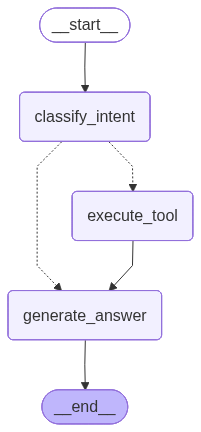

In [15]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

You should see a graph like this:

```
START → classify_intent → (conditional) → execute_tool → generate_answer → END
                                       → generate_answer → END
```

Two paths: one that uses a tool, one that skips straight to the answer.

---
## 7. Helper Function to Run Queries

A simple wrapper that runs a query through the graph and prints the result.

In [16]:
def ask(query: str):
    """Run a query through the LangGraph workflow."""

    print(f"\n{'=' * 60}")
    print(f"Query: {query}")
    print(f"{'=' * 60}")

    # Create the initial state
    initial_state = {
        "query": query,
        "tool_needed": "",
        "tool_result": "",
        "final_answer": "",
    }

    # Run the graph
    result = app.invoke(initial_state)

    # Print the final answer
    print(f"\nFinal Answer:")
    print(f"{result['final_answer']}")
    print()

    return result

---
## 8. Test It — Same Queries from Day 4

Let's run the exact same queries we used in Day 4, now through the graph.

### Test 1 — Should route to `web_search`

In [17]:
ask("What is the latest news on OpenAI?")


Query: What is the latest news on OpenAI?
  [Classify] Tool needed: web_search
  [Execute] Ran web_search — result preview: - Open AI 2")

In the latest Open AI news, the company announced staggering developments in its busi...
  [Generate] Answer ready (587 chars)

Final Answer:
The latest news on OpenAI is that the company is generating $2 billion in monthly revenue and is planning an initial public offering (IPO) that could reshape the AI industry. Despite its success, OpenAI has faced setbacks, such as discontinuing its AI video-generation app, Sora, and halting a controversial project, an erotic chatbot. However, the company is pivoting towards more scalable and productivity-driven tools, such as enterprise integrations for ChatGPT. OpenAI's IPO preparation is seen as a strategic move to focus on revenue-driven clarity and ethical product development.



{'query': 'What is the latest news on OpenAI?',
 'tool_needed': 'web_search',
 'tool_result': '- Open AI 2")\n\nIn the latest Open AI news, the company announced staggering developments in its business trajectory for 2026. OpenAI, originally celebrated for launching ChatGPT in 2022, is now generating $2 billion per month in revenue and preparing for an IPO that could redefine AI market dynamics. However, a closer look reveals that OpenAI’s path to dominance is not without hurdles. From discontinuing its AI video-generation app, Sora, to halting controversial projects like an erotic chatbot, the company illustrates the importance of recalibration even at unprecedented growth levels. From my perspective as a serial entrepreneur with 20+ years of experience building systems for scaling startups, there’s much to dissect here. [...] Table of Contents\n\n## TL;DR: Open AI News, April, 2026\n\nOpenAI is generating $2 billion in monthly revenue and planning an IPO that could reshape the AI ind

### Test 2 — Should route to `summarize`

In [18]:
long_text = """
Summarize this: Large language models (LLMs) are a type of artificial intelligence
that have been trained on vast amounts of text data. They can generate human-like text,
translate languages, write different kinds of creative content, and answer questions in
an informative way. Recent developments include models with longer context windows,
improved reasoning capabilities, and the ability to use external tools. Companies
are increasingly integrating LLMs into their products and services, from customer
support chatbots to advanced code generation tools.
""".strip()

ask(long_text)


Query: Summarize this: Large language models (LLMs) are a type of artificial intelligence
that have been trained on vast amounts of text data. They can generate human-like text,
translate languages, write different kinds of creative content, and answer questions in
an informative way. Recent developments include models with longer context windows,
improved reasoning capabilities, and the ability to use external tools. Companies
are increasingly integrating LLMs into their products and services, from customer
support chatbots to advanced code generation tools.
  [Classify] Tool needed: summarize
  [Execute] Ran summarize — result preview: Here is a summary of the text in 2-3 sentences:

Large language models (LLMs) are artificial intelli...
  [Generate] Answer ready (545 chars)

Final Answer:
The user's question is to summarize the text in 2-3 sentences. Here is a clear and helpful answer:

Large language models (LLMs) are artificial intelligence systems that can generate human-like te

{'query': 'Summarize this: Large language models (LLMs) are a type of artificial intelligence\nthat have been trained on vast amounts of text data. They can generate human-like text,\ntranslate languages, write different kinds of creative content, and answer questions in\nan informative way. Recent developments include models with longer context windows,\nimproved reasoning capabilities, and the ability to use external tools. Companies\nare increasingly integrating LLMs into their products and services, from customer\nsupport chatbots to advanced code generation tools.',
 'tool_needed': 'summarize',
 'tool_result': 'Here is a summary of the text in 2-3 sentences:\n\nLarge language models (LLMs) are artificial intelligence systems trained on vast amounts of text data, enabling them to generate human-like text, translate languages, and answer questions. Recent advancements have improved their capabilities, including longer context windows and reasoning abilities. LLMs are being increasin

### Test 3 — Should route to `save_note`

In [19]:
ask("Save this as a note: LangGraph uses nodes, edges, and state to orchestrate LLM workflows.")


Query: Save this as a note: LangGraph uses nodes, edges, and state to orchestrate LLM workflows.
  [Classify] Tool needed: save_note
  [Execute] Ran save_note — result preview: Note saved to notes/note_20260415_124559.md...
  [Generate] Answer ready (68 chars)

Final Answer:
The note has been saved to the file "notes/note_20260415_124559.md".



{'query': 'Save this as a note: LangGraph uses nodes, edges, and state to orchestrate LLM workflows.',
 'tool_needed': 'save_note',
 'tool_result': 'Note saved to notes/note_20260415_124559.md',
 'final_answer': 'The note has been saved to the file "notes/note_20260415_124559.md".'}

In [20]:
# Check that the note was actually saved
import glob

saved_notes = glob.glob("notes/*.md")
print(f"Saved notes: {saved_notes}")

if saved_notes:
    with open(saved_notes[-1]) as f:
        print(f"\nLatest note contents:\n{f.read()}")

Saved notes: ['notes\\note_20260415_124437.md', 'notes\\note_20260415_124559.md']

Latest note contents:
# Note — April 15, 2026 12:45 PM

Save this as a note: LangGraph uses nodes, edges, and state to orchestrate LLM workflows.


### Test 4 — Should answer directly (no tool needed)

In [21]:
ask("What is 2 + 2?")


Query: What is 2 + 2?
  [Classify] Tool needed: none
  [Generate] Answer ready (9 chars)

Final Answer:
2 + 2 = 4



{'query': 'What is 2 + 2?',
 'tool_needed': 'none',
 'tool_result': '',
 'final_answer': '2 + 2 = 4'}

---
## 9. Inspect the State

One of the biggest advantages of LangGraph — you can look at the **full state** at any point. No guessing what happened inside the agent.

In [22]:
# Run a query and inspect the complete state
result = ask("What is the latest news on AI agents?")

print("\n--- Full State ---")
for key, value in result.items():
    preview = str(value)[:100]
    print(f"  {key}: {preview}")


Query: What is the latest news on AI agents?
  [Classify] Tool needed: web_search
  [Execute] Ran web_search — result preview: - Iran's Strait of Hormuz Bitcoin tollbooth is the first nation-state validation of the Coinbase, Go...
  [Generate] Answer ready (1266 chars)

Final Answer:
The latest news on AI agents is that they are becoming increasingly autonomous and are being integrated into various industries, including finance, healthcare, and education. Some recent developments include:

* Iran's Bitcoin tollbooth has validated the Agentic AI payments architecture, which is a significant milestone for the technology.
* AI agents are being used to power personalized networking for 6,000 HumanX attendees, and researchers are exploring how to work with AI agents to maximize productivity and performance.
* China's Grassroots OpenClaw is rewriting the global Agentic AI race by building autonomous AI agents at scale.
* Researchers at MIT are exploring how to teach AI agents to handle exce

Compare this with Day 4 — in the manual loop, the only way to see what happened was to read through print statements. Here, every field is right there in the state dictionary.

---
## 10. Day 4 vs Day 5 — What Changed?

| | Manual Loop (Day 4) | ReAct Agent (Day 4) | LangGraph (Today) |
|---|---|---|---|
| **Control** | Full but messy | Abstracted away | Full and clean |
| **State** | Stuffed into prompt messages | Internal to agent | Explicit TypedDict |
| **Routing** | JSON parsing from LLM output | LLM reasoning (ReAct) | Conditional edges |
| **Debugging** | Print statements | Agent traces | Inspect state at each node |
| **Adding tools** | Edit prompt + tools_map | Add to tools list | Add a node + edge |
| **Visualization** | None | None | `draw_mermaid_png()` |
| **Code** | ~40 lines | ~5 lines | ~15 lines (graph setup) |

**Key takeaway:** LangGraph gives you the control of the manual loop with the cleanliness of the ReAct agent — plus visual debugging and explicit state.

In [ ]:
# Check all saved notes
saved_notes = sorted(glob.glob("notes/*.md"))
print(f"Total notes saved: {len(saved_notes)}")
for note in saved_notes:
    print(f"  - {note}")

---
## 12. What's Next — The NotebookLM Clone

Everything we built today is the foundation of the full project:

| What we built today | What it becomes in the project |
|---|---|
| `classify_intent` node | Routes between document search, web search, and direct answers |
| `execute_tool` node | Splits into `retrieve_documents` and `web_search` nodes |
| `generate_answer` node | `generate_response` — merges all context and produces the final answer |
| `save_note` tool | The note-saving feature in the Notes panel |
| `GraphState` | Expands to include `selected_docs`, `web_search_enabled`, `retrieved_context`, etc. |

The full project adds:
- **Streamlit UI** — chat interface, sidebar, notes panel
- **PDF upload + RAG** — ChromaDB vector store with metadata filtering
- **Multiple retrieval paths** — document search OR web search OR both

But the core pattern is **exactly** what you just built: state → classify → route → execute → generate.

---
## Summary

Today you learned:

1. **State** — A shared `TypedDict` that flows through the graph (replaces prompt-stuffing)
2. **Nodes** — Simple Python functions that read and update state
3. **Conditional Edges** — Route to different nodes based on the state
4. **Graph Compilation** — Wire nodes + edges, compile, invoke
5. **Visualization** — `draw_mermaid_png()` lets you see the actual workflow

The same 3 tools from Day 4. The same queries. But now orchestrated as a clean, debuggable, visible graph.